# Shmoo Plot Demo

In [1]:
# Equipment setup

import pyvisa
import serial
import shlex
import subprocess
import time
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Establish connection to the power supply
rm = pyvisa.ResourceManager("@py")

# psu = rm.open_resource('TCPIP::169.254.58.10::gpib0,7::INSTR')                  ## for the Agilent power supply

smu = rm.open_resource('TCPIP::169.254.58.10::gpib0,13::INSTR')                  ## for the Agilent power supply


psu = rm.open_resource('TCPIP::169.254.201.77::lan0::INSTR')                    ## for the Keysight power supply

# clk = rm.open_resource('TCPIP::169.254.201.101::lan0::INSTR')

# Need to verify that this is the power supply. psu_verification should be 
# something like "Keysight Technologies,E3646A,0,X.X-Y.Y-Z.Z"
psu_verification = psu.query("*IDN?")
smu_verification = smu.query("*IDN?")
# clk_verification = clk.query("*IDN?")

print("Power supply:", psu_verification)
print("SourceMeter:", smu_verification)
# print("Clock generator:", clk_verification)

# psu.write("*RST")  # Reset the power supply

start_voltage = 1.05

end_voltage = 1.05

step_size = 0.05  

start_clock = 1050

end_clock = 1050

step_size_clock = 50

# Loop through the voltage range and set the voltage
current_voltage = start_voltage 

current_clock = start_clock

# psu.write("OUTP ON, (@2)")

# # Only channel 2 works
# # psu.write("INST:SEL OUT2")
# psu.write("INST:SEL CH2")

# # Set current to 500mA
# psu.write("CURR 0.5")

# Start the clock at 20MHz
# clk.write(":OUTP1:POS ON") # Initialize clk gen channel 1 output
# clk.write(":FUNC:PATT")


# expected_output = "32767 32767 32767 32767 32767 32767 32767 32767 32767 32767"
expected_output = "4000 4400 4600 4800 4900 4a00 4b00 4c00 4c80 4d00 4d80 4e00 4e80 4f00 4f80 5000"

Power supply: Keysight Technologies,E36312A,MY57010726,1.0.4-1.0.0-1.04

SourceMeter: Keithley Instruments Inc., Model 2602A, 1264983, 2.1.5



In [39]:
current_limit = "500e-3"
voltage_limit = "0.85"

# Initialize SMU
smu.write("smub.reset()")
smu.write("smub.source.func = smub.OUTPUT_DCVOLTS")
#$ smu.write("smub.source.autorangev = smub.AUTORANGE_ON")
smu.write(f"smub.source.limiti = {current_limit}")
smu.write(f"smub.measure.rangei = {current_limit}")
smu.write(f"smub.source.limitv = {voltage_limit}")
smu.write(f"smub.source.levelv = {voltage_limit}")
smu.write(f"smub.source.rangev = {voltage_limit}")

# Clear and reset buffers
smu.write("smub.nvbuffer1.clear()")
smu.write("smub.nvbuffer1.collecttimestamps = 1")
smu.write("smub.nvbuffer1.collectsourcevalues = 1")
smu.write("smub.nvbuffer2.clear()")
smu.write("smub.nvbuffer2.collecttimestamps = 1")
smu.write("smub.nvbuffer2.collectsourcevalues = 1")

# Capture count / delay
smu.write("smub.measure.count = 700")
smu.write("smub.measure.nplc = 0.1")

# Triggers for sweeping limits
# smu.write(f"smub.trigger.source.limiti = {current_limit}")
# smu.write(f"smub.trigger.source.limitv = {voltage_limit}")

25

In [22]:
smu.write("smub.source.output = smub.OUTPUT_ON")
smu.write("smub.measure.p(smub.nvbuffer1)")
# smu.write("smub.source.output = smub.OUTPUT_OFF")
smu.write("rb1 = smub.nvbuffer1")
output = smu.query("printbuffer(1, rb1.n, rb1, rb1.timestamps, rb1.sourcevalues)")
print(output)

7.59155e-03, 0.00000e+00, 8.50000e-01, 7.57112e-03, 5.43100e-03, 8.50000e-01, 7.55210e-03, 7.19700e-03, 8.50000e-01, 7.53210e-03, 8.95000e-03, 8.50000e-01, 7.51642e-03, 1.06990e-02, 8.50000e-01, 7.49051e-03, 1.24480e-02, 8.50000e-01, 7.48711e-03, 1.41960e-02, 8.50000e-01, 7.47539e-03, 1.59450e-02, 8.50000e-01, 7.45676e-03, 1.76920e-02, 8.50000e-01, 7.44721e-03, 1.94390e-02, 8.50000e-01, 7.44464e-03, 2.11870e-02, 8.50000e-01, 7.42614e-03, 2.29370e-02, 8.50000e-01, 7.42162e-03, 2.46840e-02, 8.50000e-01, 7.42120e-03, 2.64310e-02, 8.50000e-01, 7.40510e-03, 2.82110e-02, 8.50000e-01, 7.38509e-03, 2.99680e-02, 8.50000e-01, 7.37239e-03, 3.17250e-02, 8.50000e-01, 7.35241e-03, 3.34830e-02, 8.50000e-01, 7.36789e-03, 3.52340e-02, 8.50000e-01, 7.34754e-03, 3.69830e-02, 8.50000e-01, 7.35097e-03, 3.87320e-02, 8.50000e-01, 7.32552e-03, 4.04820e-02, 8.50000e-01, 7.30995e-03, 4.22310e-02, 8.50000e-01, 7.30841e-03, 4.39800e-02, 8.50000e-01, 7.30064e-03, 4.57300e-02, 8.50000e-01, 7.28802e-03, 4.74830e-02,

[[0.0152023 0.        0.85     ]
 [0.0151582 0.005417  0.85     ]
 [0.0151377 0.007175  0.85     ]
 ...
 [0.0147597 1.22309   0.85     ]
 [0.0147606 1.22484   0.85     ]
 [0.014759  1.22659   0.85     ]]


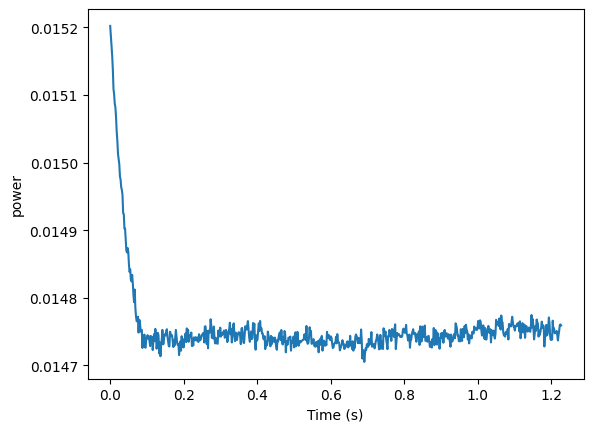

In [19]:
power_data = np.fromstring(output, dtype=float, sep=",")
power_data = power_data.reshape((-1, 3))
print(power_data)
x = power_data[:, 1]
plt.xlabel("Time (s)")
plt.ylabel("power")
plt.plot(x, power_data[:, 0])


In [34]:
# Capture count / delay
smu.write("beeper.enable = beeper.ON")
arr = [261, 261, 293, 261, 349, 329,
  261, 261, 293, 261, 392, 349,
  261, 261, 523, 440, 349, 329, 293,
  466, 466, 440, 349, 392, 349]
for freq in arr:
    smu.write(f"beeper.beep(0.6, {freq*2})")

In [40]:
smu.write("smub.source.output = smub.OUTPUT_ON")

37

5.73499e-02, 0.00000e+00, 8.50000e-01, 5.73427e-02, 2.91500e-03, 8.50000e-01, 5.72792e-02, 3.84600e-03, 8.50000e-01, 5.73392e-02, 4.76600e-03, 8.50000e-01, 5.73119e-02, 5.68200e-03, 8.50000e-01, 5.73228e-02, 6.59700e-03, 8.50000e-01, 5.75467e-02, 7.52300e-03, 8.50000e-01, 5.81211e-02, 8.44000e-03, 8.50000e-01, 5.72595e-02, 9.35400e-03, 8.50000e-01, 5.77919e-02, 1.02700e-02, 8.50000e-01, 5.74468e-02, 1.11840e-02, 8.50000e-01, 5.71716e-02, 1.20990e-02, 8.50000e-01, 5.78329e-02, 1.30150e-02, 8.50000e-01, 5.85920e-02, 1.39300e-02, 8.50000e-01, 5.84506e-02, 1.48440e-02, 8.50000e-01, 5.72545e-02, 1.57580e-02, 8.50000e-01, 5.74452e-02, 1.66720e-02, 8.50000e-01, 5.86185e-02, 1.75910e-02, 8.50000e-01, 5.75608e-02, 1.85070e-02, 8.50000e-01, 5.72374e-02, 1.94240e-02, 8.50000e-01, 5.82419e-02, 2.03380e-02, 8.50000e-01, 5.82887e-02, 2.12530e-02, 8.50000e-01, 5.85572e-02, 2.21680e-02, 8.50000e-01, 5.85677e-02, 2.30830e-02, 8.50000e-01, 5.84299e-02, 2.39980e-02, 8.50000e-01, 5.84200e-02, 2.49110e-02,

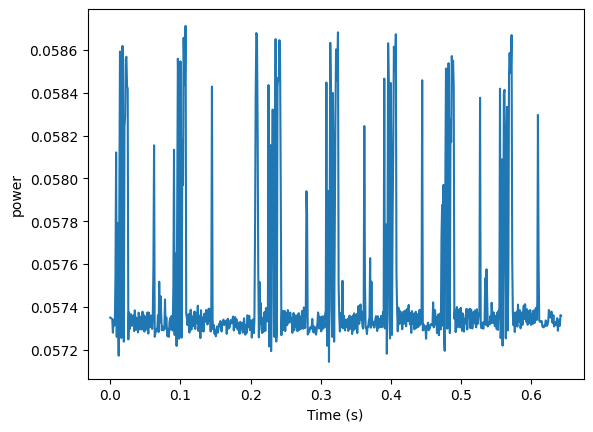

In [44]:
# collect power data and plot
smu.write("smub.nvbuffer1.clear()")
smu.write("smub.nvbuffer1.collecttimestamps = 1")
smu.write("smub.nvbuffer1.collectsourcevalues = 1")

smu.write("smub.measure.p(smub.nvbuffer1)")
# Capture count / delay
smu.write("smub.measure.count = 700")
smu.write("smub.measure.nplc = 0.05")

smu.write("smub.measure.p(smub.nvbuffer1)")
# smu.write("smub.source.output = smub.OUTPUT_OFF")
smu.write("rb1 = smub.nvbuffer1")
output = smu.query("printbuffer(1, rb1.n, rb1, rb1.timestamps, rb1.sourcevalues)")
print(output)

power_data = np.fromstring(output, dtype=float, sep=",")
power_data = power_data.reshape((-1, 3))
print(power_data)
x = power_data[:, 1]
plt.xlabel("Time (s)")
plt.ylabel("power")
plt.plot(x, power_data[:, 0])

In [20]:
smu.write("smub.source.output = smub.OUTPUT_OFF")

38

In [ ]:
# ^^^^^^ all of jasmines stuff

In [2]:
while current_voltage <= end_voltage: # Set the voltage 
     while current_clock <= end_clock:
          # remake to adjust with the frequency
          subprocess.run(["make", "clean"], cwd="../../")

          with open("../../platform/dsp24/freq.h", "w") as f:
               f.write('''#ifndef __FREQ_H
                         #define __FREQ_H
                         ''')
               f.write(f'''#define MTIME_FREQ     {current_clock}000000
                         #define SYS_CLK_FREQ   {current_clock}000000
                         ''')
               f.write("#endif")

          cmake_args_soc = shlex.split("/tools/C/ee290-fa24-2/.conda-env/bin/cmake -S ./ -B ./build/ -D CMAKE_TOOLCHAIN_FILE=./riscv-gcc.cmake -DCHIP=dsp24")
          cmake_args_shmoo = shlex.split("/tools/C/ee290-fa24-2/.conda-env/bin/cmake --build ./build/ --target shmoo_bench")

          subprocess.run(cmake_args_soc, cwd="../../")
          subprocess.run(cmake_args_shmoo, cwd="../../")

          # clk.write(":FREQ 100MHz")
          print(f"**Clock set to: {current_clock}MHz**")   
          psu.write(f"VOLT {current_voltage}")

          voltage = psu.query("VOLT?") 
          print(f"**Voltage set to: {voltage}V**") 
          ratio_integer = hex(int(current_clock / 50))
          openocd_args = shlex.split("/tools/C/ee290-fa24-2/.conda-env/bin/openocd -f platform/dsp24/dsp24.cfg")
          gdb_args = shlex.split(f'riscv64-unknown-elf-gdb ../../build/shmoo_bench.elf --eval-command="target extended-remote localhost:3333" --eval-command="monitor reset" --eval-command="set *0x14006C={ratio_integer}" --eval-command="load" --eval-command="continue"')

          openocd = subprocess.Popen(openocd_args, cwd="/tools/C/angle/shmoo")
          gdb = subprocess.Popen(gdb_args)

          measured_voltages = []
          measured_currents = []
          start_time = time.time()
          timeout = False
          
          with serial.Serial('/dev/ttyUSB1', 115200, timeout=7) as ser:
               while (ser.inWaiting() == 0):
                    ## measure the voltage + current
                    if time.time() - start_time >= 7:
                         timeout = True
                         
                         break
                    measured_voltages.append(psu.query("MEAS:VOLT?"))
                    measured_currents.append(psu.query("MEAS:CURR?"))
                    # measured_voltages.append(5)
                    # measured_currents.append(5)
               if timeout:
                    length = min(len(measured_currents), len(measured_voltages))
                    print(f"{current_clock}MHZ, {current_voltage}V: Timed out")
                    power_consumption = sum([float(measured_voltages[i]) * float(measured_currents[i]) for i in range(length)]) / length
                    for freq in range(current_clock, end_clock + 1, step_size_clock):
                         with open('../../output_jtag.txt', 'a') as file:
                              file.write(f"Freq: {freq}, Voltage: {current_voltage}, Output: Invalid, Power: {power_consumption}\n")
                    gdb.kill()
                    gdb.wait()
                    openocd.kill()
                    openocd.wait()
                    print("Reset the chip if you haven't already")
                    time.sleep(5)
                    
                    break
               else:
                    line = ser.readline()
                    print(line)
                    new_line = line.decode("utf-8")


                    res = "Valid"
                    if not new_line.strip() == expected_output.strip():
                         res = "Invalid"
                         # break

                    print(f"{current_clock}MHZ, {current_voltage}V: {res}")
                    
                    ## calculate power consumption
                    length = min(len(measured_currents), len(measured_voltages))
                    power_consumption = sum([float(measured_voltages[i]) * float(measured_currents[i]) for i in range(length)]) / length
                    with open('../../output_jtag.txt', 'a') as file:
                         file.write(f"Freq: {current_clock}, Voltage: {current_voltage}, Output: {res}, Power: {power_consumption}\n")
                         gdb.terminate()
                         gdb.wait()
          gdb.kill()
          gdb.wait()
          openocd.kill()
          openocd.wait()
          current_clock += step_size_clock
          time.sleep(3)
     print("Reset the chip if you haven't already")
     time.sleep(2)
     current_voltage += step_size
     current_clock = start_clock

     #      current_voltage += step_size
     # current_voltage = start_voltage
     # current_clock += step_size_clock

print("Finished")

# psu.close()

current_clock = start_clock
current_voltage = start_voltage

rm -rf build
-- The ASM compiler identification is GNU
-- Found assembler: /tools/C/ee290-fa24-2/.conda-env/riscv-tools/bin/riscv64-unknown-elf-gcc
-- The C compiler identification is GNU 13.2.0
-- The CXX compiler identification is GNU 13.2.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /tools/C/ee290-fa24-2/.conda-env/riscv-tools/bin/riscv64-unknown-elf-gcc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /tools/C/ee290-fa24-2/.conda-env/riscv-tools/bin/riscv64-unknown-elf-g++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Including HTIF to target
-- Including CLINT to target
-- ================ Glossy config ================
--  Building for CHIP: "dsp24"
--  Reading config from "/bwrcq/C/angle/shmoo/platform/dsp24/CMakeLists.txt"
--  Termin

/bwrcq/C/angle/shmoo/driver/rocket-chip-blocks/uart/uart.c: In function 'uart_receive':
/bwrcq/C/angle/shmoo/driver/rocket-chip-blocks/uart/uart.c:35:78: warning: unused parameter 'timeout' [-Wunused-parameter]
   35 | Status uart_receive(UART_Type *UARTx, uint8_t *data, uint16_t size, uint32_t timeout) {
      |                                                                     ~~~~~~~~~^~~~~~~
/bwrcq/C/angle/shmoo/driver/rocket-chip-blocks/uart/uart.c: In function 'uart_transmit':
/bwrcq/C/angle/shmoo/driver/rocket-chip-blocks/uart/uart.c:50:85: warning: unused parameter 'timeout' [-Wunused-parameter]
   50 | Status uart_transmit(UART_Type *UARTx, const uint8_t *data, uint16_t size, uint32_t timeout) {
      |                                                                            ~~~~~~~~~^~~~~~~


[  5%] Built target uart
[  7%] Building C object driver/intel/pll/CMakeFiles/intel-pll.dir/pll.c.obj
[ 10%] Linking C static library libintel-pll.a
[ 10%] Built target intel-pll
[ 12%] Building C object driver/rocket-chip/clint/CMakeFiles/clint.dir/clint.c.obj
[ 15%] Linking C static library libclint.a
[ 15%] Built target clint
[ 17%] Building C object driver/rocket-chip/rocketcore/CMakeFiles/rocketcore.dir/rocketcore.c.obj
[ 20%] Linking C static library librocketcore.a
[ 20%] Built target rocketcore
[ 23%] Building C object driver/rocket-chip-blocks/i2c/CMakeFiles/i2c.dir/i2c.c.obj
[ 25%] Linking C static library libi2c.a


/bwrcq/C/angle/shmoo/driver/rocket-chip-blocks/i2c/i2c.c: In function 'i2c_init':
/bwrcq/C/angle/shmoo/driver/rocket-chip-blocks/i2c/i2c.c:13:45: warning: unused parameter 'I2C_init' [-Wunused-parameter]
   13 | void i2c_init(I2C_Type *I2Cx, I2C_InitType *I2C_init) {
      |                               ~~~~~~~~~~~~~~^~~~~~~~
/bwrcq/C/angle/shmoo/driver/rocket-chip-blocks/i2c/i2c.c: In function 'i2c_wait_for_flag':
/bwrcq/C/angle/shmoo/driver/rocket-chip-blocks/i2c/i2c.c:30:9: warning: implicit declaration of function 'CLINT_getTime' [-Wimplicit-function-declaration]
   30 |     if (CLINT_getTime() > (timestart + timeout)) {
      |         ^~~~~~~~~~~~~
/bwrcq/C/angle/shmoo/driver/rocket-chip-blocks/i2c/i2c.c:30:25: warning: comparison of integer expressions of different signedness: 'int' and 'uint32_t' {aka 'unsigned int'} [-Wsign-compare]
   30 |     if (CLINT_getTime() > (timestart + timeout)) {
      |                         ^
/bwrcq/C/angle/shmoo/driver/rocket-chip-blocks/i2c/i

[ 25%] Built target i2c
[ 28%] Building C object driver/rocket-chip-blocks/spi/CMakeFiles/spi.dir/spi.c.obj


...

/bwrcq/C/ee290-fa24-2/.conda-env/riscv-tools/bin/../lib/gcc/riscv64-unknown-elf/13.2.0/../../../../riscv64-unknown-elf/bin/ld: warning: shmoo_bench.elf has a LOAD segment with RWX permissions
Open On-Chip Debugger 0.12.0+dev-00772-g40d58ce52 (2024-11-07-12:34)
Licensed under GNU GPL v2
For bug reports, read
	http://openocd.org/doc/doxygen/bugs.html
Error: unable to open ftdi device with description '*', serial '*' at bus location '*'



**Clock set to: 1050MHz**
**Voltage set to: +1.05000000E+00
V**
GNU gdb (GDB) 14.1
Copyright (C) 2023 Free Software Foundation, Inc.
License GPLv3+: GNU GPL version 3 or later <http://gnu.org/licenses/gpl.html>
This is free software: you are free to change and redistribute it.
There is NO WARRANTY, to the extent permitted by law.
Type "show copying" and "show warranty" for details.
This GDB was configured as "--host=x86_64-pc-linux-gnu --target=riscv64-unknown-elf".
Type "show configuration" for configuration details.
For bug reporting instructions, please see:
<https://www.gnu.org/software/gdb/bugs/>.
Find the GDB manual and other documentation resources online at:
    <http://www.gnu.org/software/gdb/documentation/>.

For help, type "help".
Type "apropos word" to search for commands related to "word"...
Reading symbols from ../../build/shmoo_bench.elf...


SerialException: [Errno 2] could not open port /dev/ttyUSB1: [Errno 2] No such file or directory: '/dev/ttyUSB1'

localhost:3333: Network is unreachable.
"monitor" command not supported by this target.
Cannot access memory at address 0x14006c
You can't do that when your target is `exec'
The program is not being run.


(gdb) 

#### Generate Shmoo Plot

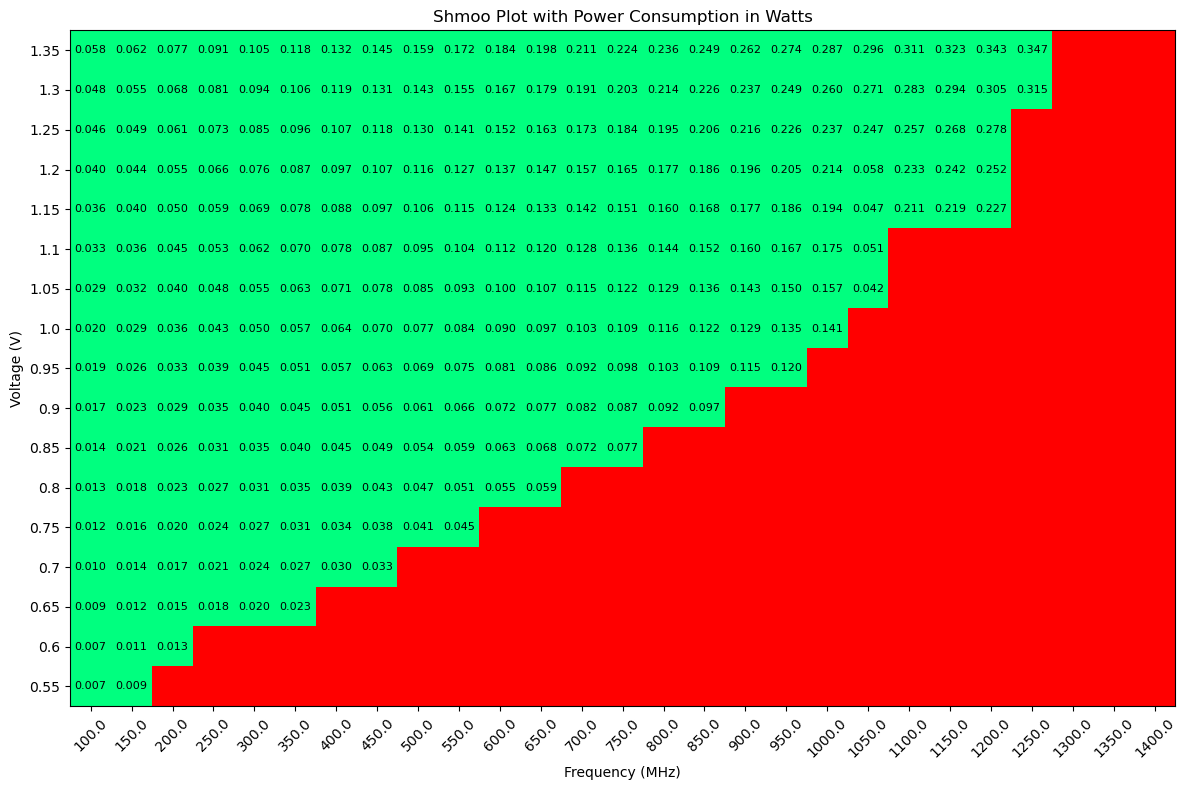

In [66]:
import matplotlib.pyplot as plt
import numpy as np

def read_data(file_name):
    freq_values = []
    voltage_values = []
    valid_values = []
    power_values = []

    with open(file_name, 'r') as file:
        for line in file:
            parts = line.strip().split(', ')
            freq = float(parts[0].split(': ')[1])
            voltage = round(float(parts[1].split(': ')[1]), 2)
            valid = parts[2].split(': ')[1]
            power = float(parts[3].split(': ')[1])

            freq_values.append(freq)
            voltage_values.append(voltage)
            valid_values.append(valid)
            power_values.append(power)
    
    return freq_values, voltage_values, valid_values, power_values

file_name = '../../output_jtag.txt'

freq_values, voltage_values, valid_values, power_values = read_data(file_name)

unique_freqs = np.unique(freq_values)
unique_voltages = np.unique(voltage_values)

shmoo_plot = np.zeros((len(unique_voltages), len(unique_freqs)))
power_plot = np.zeros((len(unique_voltages), len(unique_freqs)))

for i, freq in enumerate(unique_freqs):
    for j, voltage in enumerate(unique_voltages):
        validity = valid_values[i * len(unique_voltages) + j]
        if validity == "Valid":
            shmoo_plot[j, i] = 1
            power_plot[j, i] = power_values[i * len(unique_voltages) + j]

plt.figure(figsize=(12, 8))

cmap = plt.cm.colors.ListedColormap(['red', 'springgreen'])

plt.imshow(shmoo_plot, cmap=cmap, aspect='auto', origin='lower')

for i in range(len(unique_freqs)):
    for j in range(len(unique_voltages)):
        if shmoo_plot[j, i] == 1:  # Valid
            plt.text(i, j, f'{power_plot[j, i]:.3f}', ha='center', va='center', fontsize=8, color='black')

plt.xlabel('Frequency (MHz)')
plt.ylabel('Voltage (V)')
plt.title('Shmoo Plot with Power Consumption in Watts')

plt.xticks(np.arange(len(unique_freqs)), unique_freqs, rotation=45)
plt.yticks(np.arange(len(unique_voltages)), unique_voltages)

plt.tight_layout()
plt.show()
